In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve, ConfusionMatrixDisplay
)
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

pd.set_option("display.max_columns", 100)

In [35]:
df = pd.read_csv("dataset\Churn_Modelling.csv")
print(df.shape)
df.head()

(10000, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [36]:
print("Missing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("\nData types:\n", df.dtypes)

Missing values:
 RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

Duplicate rows: 0

Data types:
 RowNumber            int64
CustomerId           int64
Surname             object
CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object


# EDA

In [37]:
df["Exited"].value_counts(normalize=True)

Exited
0    0.7963
1    0.2037
Name: proportion, dtype: float64

C:\Users\USER\AppData\Local\Temp\ipykernel_22404\1883409986.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(age_bins)["Exited"].mean().plot(kind="bar", ax=axes[0])


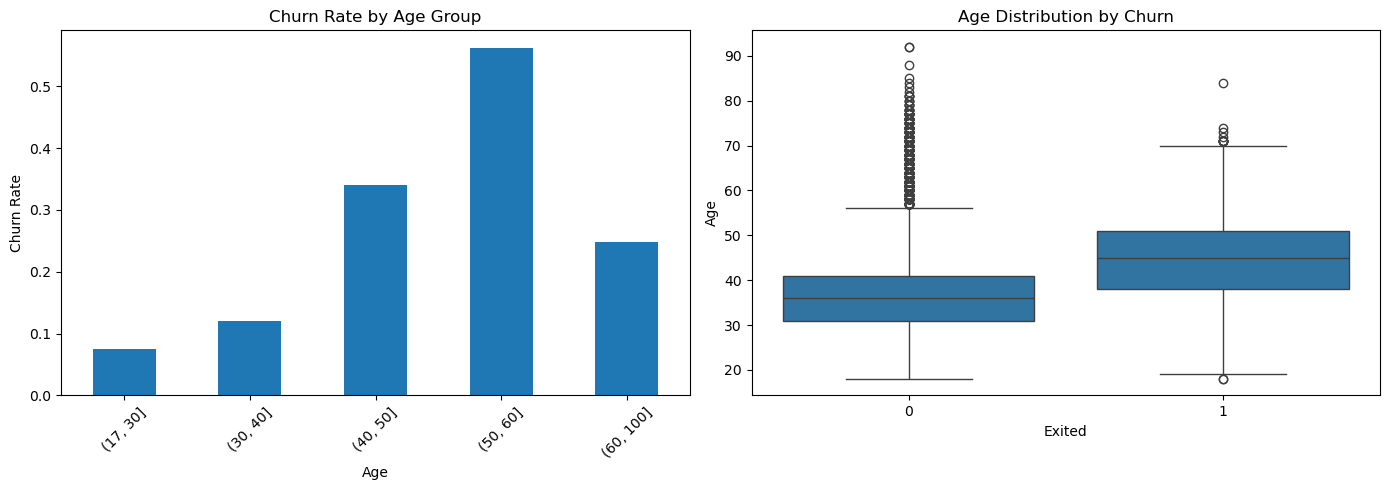

In [38]:
# Which Age group churns the most?
fig, axes = plt.subplots(1, 2, figsize=(14,5))

age_bins = pd.cut(df["Age"], bins=[17,30,40,50,60,100])
df.groupby(age_bins)["Exited"].mean().plot(kind="bar", ax=axes[0])
axes[0].set_title("Churn Rate by Age Group")
axes[0].set_ylabel("Churn Rate")
axes[0].tick_params(axis='x', rotation=45)

sns.boxplot(x="Exited", y="Age", data=df, ax=axes[1])
axes[1].set_title("Age Distribution by Churn")

plt.tight_layout()
plt.show()

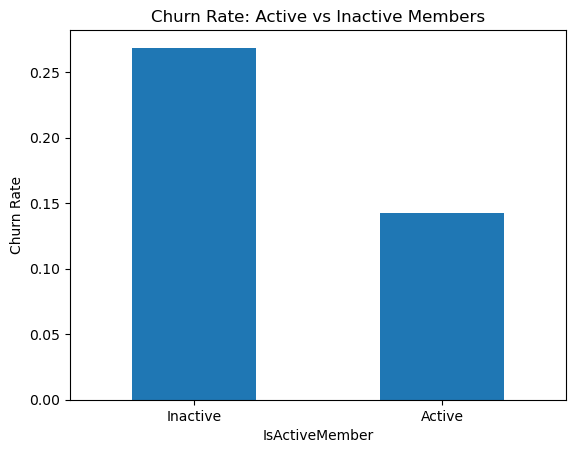

In [39]:
# Do inactive members churn more?
df.groupby("IsActiveMember")["Exited"].mean().plot(kind="bar")
plt.title("Churn Rate: Active vs Inactive Members")
plt.ylabel("Churn Rate")
plt.xticks([0,1], ["Inactive", "Active"], rotation=0)
plt.show()

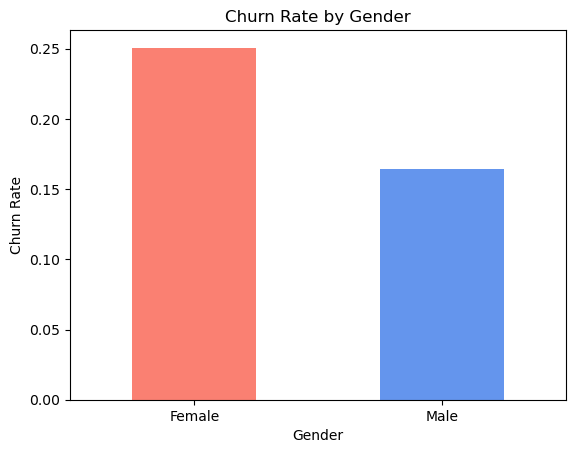

In [40]:
# Does gender matter?
df.groupby("Gender")["Exited"].mean().plot(kind="bar", color=["salmon","cornflowerblue"])
plt.title("Churn Rate by Gender")
plt.ylabel("Churn Rate")
plt.xticks(rotation=0)
plt.show()

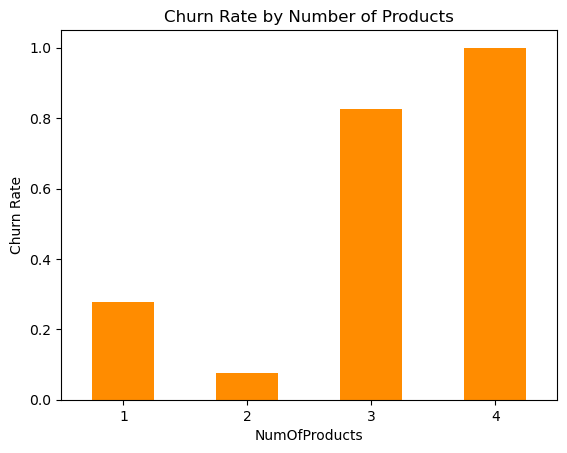

NumOfProducts
1    5084
2    4590
3     266
4      60
Name: count, dtype: int64
NumOfProducts
1    0.277144
2    0.075817
3    0.827068
4    1.000000
Name: Exited, dtype: float64


In [41]:
# Does number of product affect churn?
df.groupby("NumOfProducts")["Exited"].mean().plot(kind="bar", color="darkorange")
plt.title("Churn Rate by Number of Products")
plt.ylabel("Churn Rate")
plt.xticks(rotation=0)
plt.show()

print(df["NumOfProducts"].value_counts())
print(df.groupby("NumOfProducts")["Exited"].mean())

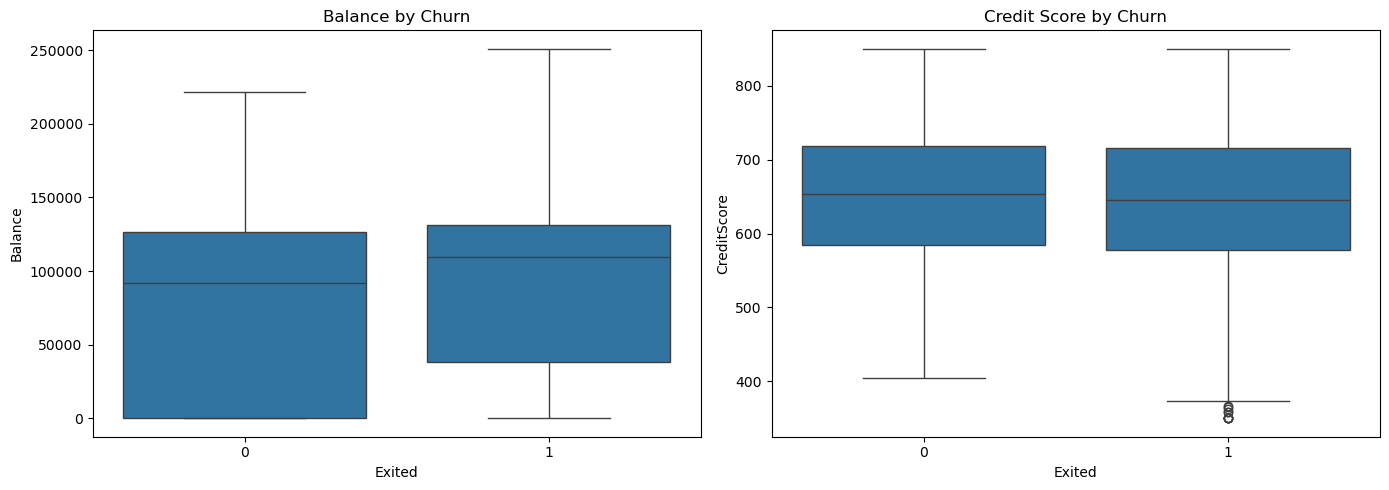

Balance correlation with churn: 0.11853276877163386
CreditScore correlation with churn: -0.02709353975465778


In [42]:
# Does balance affect churn?
fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.boxplot(x="Exited", y="Balance", data=df, ax=axes[0])
axes[0].set_title("Balance by Churn")

sns.boxplot(x="Exited", y="CreditScore", data=df, ax=axes[1])
axes[1].set_title("Credit Score by Churn")

plt.tight_layout()
plt.show()

print("Balance correlation with churn:", df["Balance"].corr(df["Exited"]))
print("CreditScore correlation with churn:", df["CreditScore"].corr(df["Exited"]))

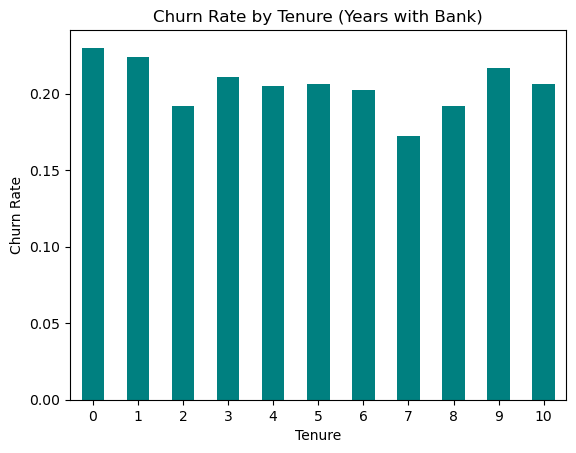

In [43]:
# Does credit score affect churn?
df.groupby("Tenure")["Exited"].mean().plot(kind="bar", color="teal")
plt.title("Churn Rate by Tenure (Years with Bank)")
plt.ylabel("Churn Rate")
plt.xticks(rotation=0)
plt.show()

# Data Preprocessing

In [44]:
df_model = df.drop(columns=["RowNumber", "CustomerId", "Surname"])

numeric_features = ["CreditScore", "Age", "Tenure", "Balance", "NumOfProducts", "EstimatedSalary"]
categorical_features = ["Gender"]
binary_features = ["HasCrCard", "IsActiveMember"]  # already 0/1, no encoding needed

X = df_model[numeric_features + categorical_features + binary_features]
y = df_model["Exited"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("bin", "passthrough", binary_features),
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)

Train shape: (8000, 9)  Test shape: (2000, 9)


# ML Models

In [45]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Decision Tree": DecisionTreeClassifier(random_state=42, max_depth=6, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(
        n_estimators=300, max_depth=10, max_features="sqrt",
        class_weight="balanced", random_state=42, n_jobs=-1
    ),
    "KNN": KNeighborsClassifier(n_neighbors=15, weights="distance"),
}

fitted_models = {}
for name, clf in models.items():
    pipe = Pipeline(steps=[("preprocessor", preprocessor), ("classifier", clf)])
    pipe.fit(X_train, y_train)
    fitted_models[name] = pipe
    print(f"Trained: {name}")

Trained: Logistic Regression
Trained: Decision Tree
Trained: Random Forest
Trained: KNN


In [46]:
baseline_acc = 1 - y_test.mean()
print(f"Naive 'always predict stays' baseline accuracy: {baseline_acc:.4f}\n")

results = []
for name, pipe in fitted_models.items():
    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba),
    })

    print(f"--- {name} ---")
    print(classification_report(y_test, y_pred))

results_df = pd.DataFrame(results).sort_values("ROC-AUC", ascending=False)
results_df

Naive 'always predict stays' baseline accuracy: 0.7965

--- Logistic Regression ---
              precision    recall  f1-score   support

           0       0.91      0.70      0.79      1593
           1       0.38      0.72      0.50       407

    accuracy                           0.71      2000
   macro avg       0.64      0.71      0.65      2000
weighted avg       0.80      0.71      0.73      2000

--- Decision Tree ---
              precision    recall  f1-score   support

           0       0.92      0.74      0.82      1593
           1       0.42      0.76      0.54       407

    accuracy                           0.74      2000
   macro avg       0.67      0.75      0.68      2000
weighted avg       0.82      0.74      0.76      2000

--- Random Forest ---
              precision    recall  f1-score   support

           0       0.91      0.87      0.89      1593
           1       0.57      0.65      0.60       407

    accuracy                           0.83      2000


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
2,Random Forest,0.8270,0.565591,0.646192,0.603211,0.847630
3,KNN,0.8385,0.741379,0.316953,0.444062,0.821638
1,Decision Tree,0.7405,0.423497,0.761671,0.544337,0.820912
0,Logistic Regression,0.7055,0.381818,0.722359,0.499575,0.774068


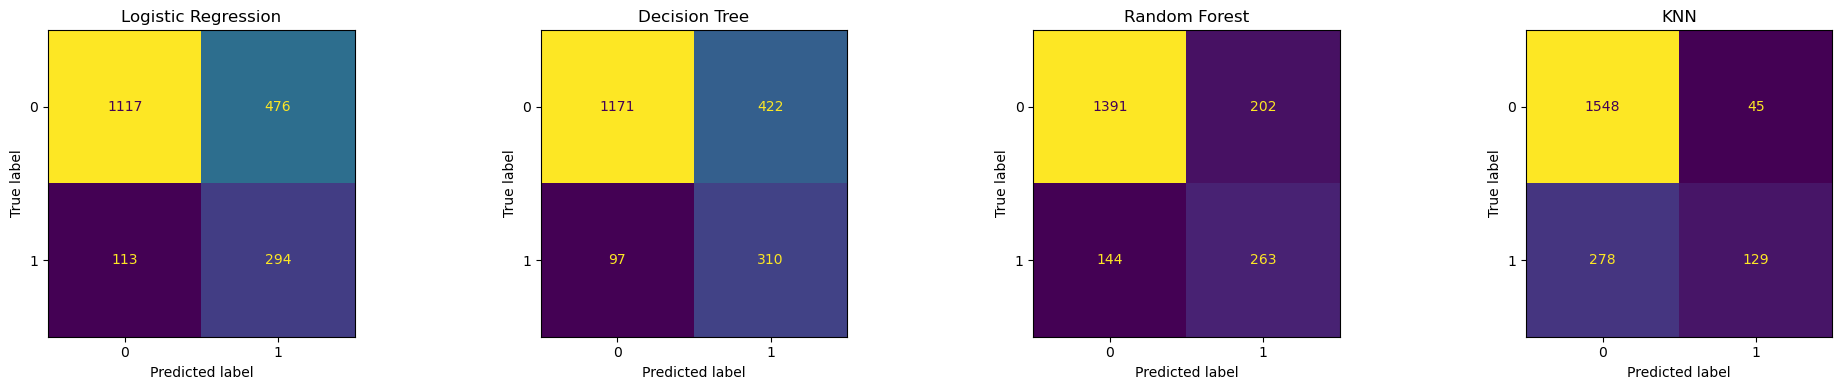

In [47]:
fig, axes = plt.subplots(1, 4, figsize=(20,4))
for ax, (name, pipe) in zip(axes, fitted_models.items()):
    y_pred = pipe.predict(X_test)
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax, colorbar=False)
    ax.set_title(name)
plt.tight_layout()
plt.show()

In [48]:
# Cross validation
best_model_name = results_df.iloc[0]["Model"]
print("Best model by ROC-AUC (single split):", best_model_name)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(fitted_models[best_model_name], X, y, cv=cv, scoring="roc_auc")
print(f"Cross-validated ROC-AUC: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

Best model by ROC-AUC (single split): Random Forest
Cross-validated ROC-AUC: 0.8453 (+/- 0.0056)


In [49]:
# Hyper parameter tuning
param_grid = {
    "classifier__n_estimators": [200, 300, 500],
    "classifier__max_depth": [6, 10, 14, None],
    "classifier__min_samples_leaf": [1, 5, 10],
}

rf_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=-1))
])

grid_search = GridSearchCV(rf_pipe, param_grid, cv=5, scoring="roc_auc", n_jobs=-1)
grid_search.fit(X_train, y_train)

print("Best params:", grid_search.best_params_)
print("Best CV ROC-AUC:", grid_search.best_score_)

tuned_model = grid_search.best_estimator_
tuned_auc = roc_auc_score(y_test, tuned_model.predict_proba(X_test)[:, 1])
print("Tuned model ROC-AUC on held-out test set:", tuned_auc)

Best params: {'classifier__max_depth': 10, 'classifier__min_samples_leaf': 5, 'classifier__n_estimators': 200}
Best CV ROC-AUC: 0.8462178925369109
Tuned model ROC-AUC on held-out test set: 0.8510035459188001


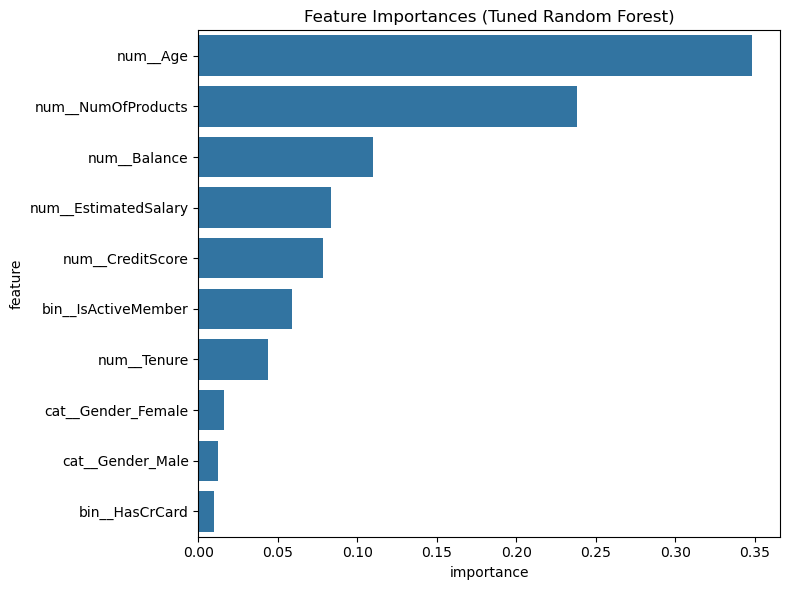

,feature,importance
1,num__Age,0.348544
4,num__NumOfProducts,0.238351
3,num__Balance,0.109961
5,num__EstimatedSalary,0.083657
0,num__CreditScore,0.078306
9,bin__IsActiveMember,0.058985
2,num__Tenure,0.043763
6,cat__Gender_Female,0.016349
7,cat__Gender_Male,0.012308
8,bin__HasCrCard,0.009777


In [50]:
feature_names = tuned_model.named_steps["preprocessor"].get_feature_names_out()
importances = tuned_model.named_steps["classifier"].feature_importances_

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(x="importance", y="feature", data=importance_df)
plt.title("Feature Importances (Tuned Random Forest)")
plt.tight_layout()
plt.show()

importance_df

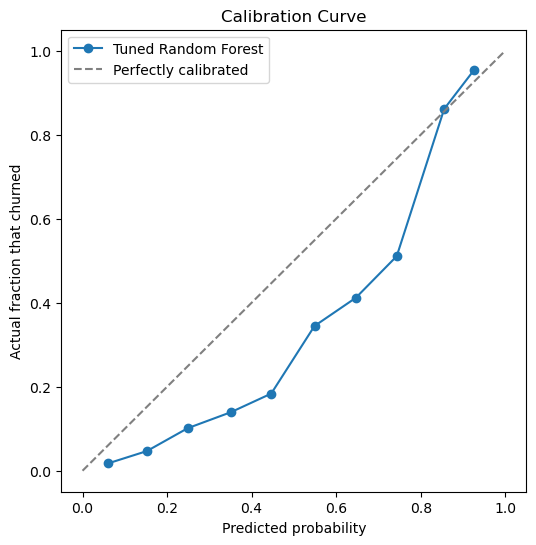

In [51]:
#calibration
y_proba_tuned = tuned_model.predict_proba(X_test)[:, 1]
frac_pos, mean_pred = calibration_curve(y_test, y_proba_tuned, n_bins=10)

plt.figure(figsize=(6,6))
plt.plot(mean_pred, frac_pos, marker="o", label="Tuned Random Forest")
plt.plot([0,1], [0,1], linestyle="--", color="gray", label="Perfectly calibrated")
plt.xlabel("Predicted probability")
plt.ylabel("Actual fraction that churned")
plt.title("Calibration Curve")
plt.legend()
plt.show()

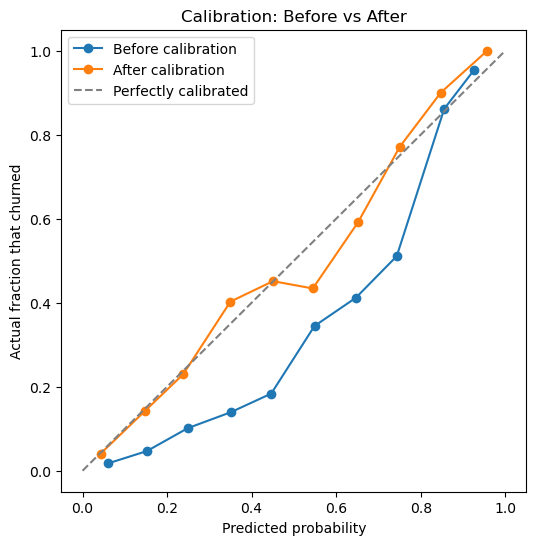

In [52]:
# calibration
calibrated_model = CalibratedClassifierCV(tuned_model, method="isotonic", cv=5)
calibrated_model.fit(X_train, y_train)

y_proba_cal = calibrated_model.predict_proba(X_test)[:, 1]
frac_pos_cal, mean_pred_cal = calibration_curve(y_test, y_proba_cal, n_bins=10)

plt.figure(figsize=(6,6))
plt.plot(mean_pred, frac_pos, marker="o", label="Before calibration")
plt.plot(mean_pred_cal, frac_pos_cal, marker="o", label="After calibration")
plt.plot([0,1], [0,1], linestyle="--", color="gray", label="Perfectly calibrated")
plt.xlabel("Predicted probability")
plt.ylabel("Actual fraction that churned")
plt.title("Calibration: Before vs After")
plt.legend()
plt.show()

In [53]:
# Final model & Risk level mapping
final_model = calibrated_model

CHURN_THRESHOLD = 0.16  # chosen to catch ~82% of actual churners

def predict_churn(customer):
    """
    customer: dict with keys CreditScore, Geography, Gender, Age, Tenure,
              Balance, NumOfProducts, HasCrCard, IsActiveMember, EstimatedSalary
    Returns: dict with probability (%), flagged_for_action, risk_level, recommendation
    """
    input_df = pd.DataFrame([customer])
    proba = final_model.predict_proba(input_df)[0, 1]
    proba_pct = proba * 100

    flagged = proba >= CHURN_THRESHOLD

    if proba_pct >= 70:
        risk_level = "High"
        recommendation = "Contact this customer with a retention offer and review their account activity."
    elif proba_pct >= 40:
        risk_level = "Medium"
        recommendation = "Monitor this customer and consider a proactive engagement touchpoint."
    elif flagged:
        risk_level = "Elevated"
        recommendation = "Add to retention outreach queue — model recall threshold met, review before outreach."
    else:
        risk_level = "Low"
        recommendation = "No action needed at this time."

    return {
        "probability_of_churn": round(proba_pct, 1),
        "flagged_for_retention_queue": bool(flagged),
        "risk_level": risk_level,
        "recommendation": recommendation
    }


example_customer = {
    "CreditScore": 600,
    "Gender": "Female",
    "Age": 52,
    "Tenure": 3,
    "Balance": 120000,
    "NumOfProducts": 1,
    "HasCrCard": 1,
    "IsActiveMember": 0,
    "EstimatedSalary": 80000,
}

result = predict_churn(example_customer)
print(result)

{'probability_of_churn': np.float64(91.6), 'flagged_for_retention_queue': True, 'risk_level': 'High', 'recommendation': 'Contact this customer with a retention offer and review their account activity.'}


In [54]:
borderline_customer = {
    "CreditScore": 650,
    "Gender": "Male",
    "Age": 38,
    "Tenure": 5,
    "Balance": 60000,
    "NumOfProducts": 2,
    "HasCrCard": 1,
    "IsActiveMember": 1,
    "EstimatedSalary": 70000,
}

print(predict_churn(borderline_customer))

{'probability_of_churn': np.float64(4.0), 'flagged_for_retention_queue': False, 'risk_level': 'Low', 'recommendation': 'No action needed at this time.'}


In [55]:
borderline_customer = {
    "CreditScore": 706,
    "Gender": "Female",
    "Age": 29,
    "Tenure": 6,
    "Balance": 185544.36,
    "NumOfProducts": 1,
    "HasCrCard": 1,
    "IsActiveMember": 0,
    "EstimatedSalary": 171037.63,
}

print(predict_churn(borderline_customer))

{'probability_of_churn': np.float64(28.8), 'flagged_for_retention_queue': True, 'risk_level': 'Elevated', 'recommendation': 'Add to retention outreach queue — model recall threshold met, review before outreach.'}


In [56]:
import joblib
joblib.dump(final_model, "churn_model.joblib")

['churn_model.joblib']

In [57]:
pip install -r requirements.txt
python app.py

SyntaxError: invalid syntax (1409602490.py, line 1)